# Notebook 04 — Evaluation & Cluster Interpretation

Compare all algorithms across both datasets, interpret clusters.

In [1]:
import sys; sys.path.insert(0, '..')
import pickle, numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse import load_npz
from src.evaluation import (get_top_terms, get_cluster_examples,
                             cluster_size_distribution, best_result)


## 1. Full Metrics Comparison — Both Datasets

In [2]:
ng = pd.read_csv('../outputs/reports/clustering_metrics_newsgroups.csv')
ng['dataset'] = 'newsgroups'
wk = pd.read_csv('../outputs/reports/clustering_metrics_wikipedia.csv')
wk['dataset'] = 'wikipedia'
all_metrics = pd.concat([ng, wk], ignore_index=True)

# Best per algorithm × dataset
summary = (all_metrics.groupby(['dataset','algorithm'])
           .apply(lambda g: g.loc[g['silhouette'].idxmax()])
           [['k','silhouette','davies_bouldin','calinski_harabasz','runtime_s']]
           .reset_index())
print(summary.to_string(index=False))


   dataset    algorithm  k  silhouette  davies_bouldin  calinski_harabasz  runtime_s
newsgroups          gmm 20    0.040600        3.631281         202.706111   1.866209
newsgroups hierarchical 20    0.027888        3.811752         178.055596   5.518836
newsgroups       kmeans 25    0.054771        3.615452         205.165828   0.941861
 wikipedia          gmm 20    0.122062        2.858787          11.799131   0.011662
 wikipedia hierarchical 20    0.123385        2.756438          12.164340   0.004001
 wikipedia       kmeans 25    0.137313        2.571922          11.403546   0.020142


## 2. Silhouette Heatmap

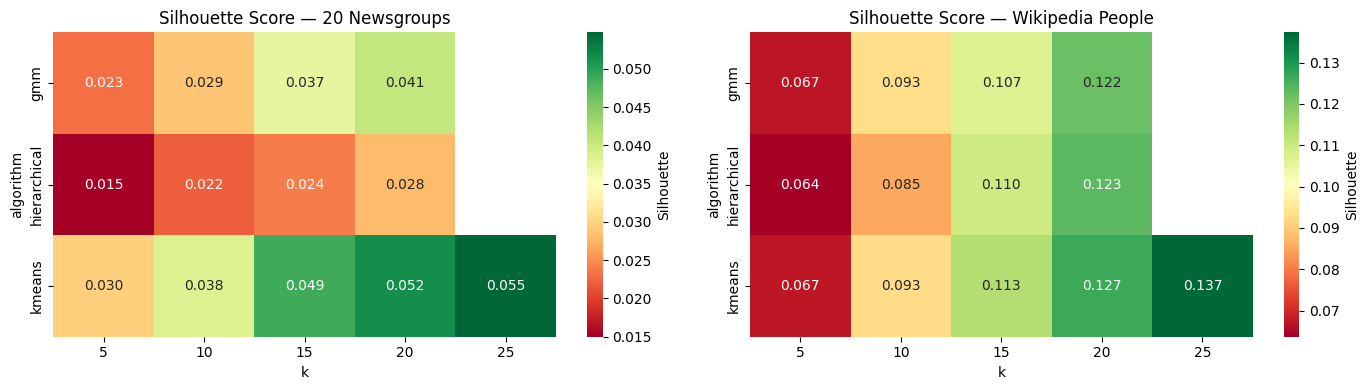

In [3]:
pivot_ng = ng.groupby(['algorithm','k'])['silhouette'].max().unstack()
pivot_wk = wk.groupby(['algorithm','k'])['silhouette'].max().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pivot, title in zip(axes, [pivot_ng, pivot_wk], ['20 Newsgroups', 'Wikipedia People']):
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, cbar_kws={'label':'Silhouette'})
    ax.set_title(f'Silhouette Score — {title}')
plt.tight_layout(); plt.savefig('../outputs/figures/evaluation_heatmap.png', bbox_inches='tight')
plt.show()


## 3. Deep Dive — Best Model: 20 Newsgroups

In [4]:
with open('../data/processed/newsgroups_clean.pkl','rb') as f: corpus_ng = pickle.load(f)
vec_ng   = joblib.load('../models/tfidf_newsgroups.pkl')
X_ng     = np.load('../data/processed/X_reduced_newsgroups.npy')
X_tf_ng  = load_npz('../data/processed/X_tfidf_newsgroups.npz')

best_ng  = best_result(ng, algorithm='kmeans', metric='silhouette')
k_ng     = int(best_ng['k'])
model_ng = joblib.load(f'../models/kmeans_newsgroups_k{k_ng}.pkl')
labels_ng = model_ng.predict(X_ng)
top_terms_ng = get_top_terms(labels_ng, vec_ng, X_tf_ng, n=12)
examples_ng  = get_cluster_examples(labels_ng, corpus_ng, n=1, snippet_len=200)

print(f"Best KMeans — 20 Newsgroups — k={k_ng}  sil={best_ng['silhouette']:.4f}\n")
for cid in sorted(top_terms_ng)[:10]:
    terms = " | ".join(top_terms_ng[cid][:8])
    doc   = examples_ng[cid][0] if examples_ng[cid] else ''
    size  = int((labels_ng == cid).sum())
    print(f"  Cluster {cid:2d} ({size:4d} docs)")
    print(f"    Terms  : {terms}")
    print(f"    Sample : {doc[:120]}")
    print()


Best KMeans — 20 Newsgroups — k=25  sil=0.0548

  Cluster  0 (2523 docs)
    Terms  : like | would | get | one | know | article | well | good
    Sample : dallas try tech support may line one get started

  Cluster  1 ( 454 docs)
    Terms  : game | espn | baseball | hockey | playoff | fan | night | last
    Sample : sure bashers pen fan pretty confused lack kind post recent pen massacre devil actually bit puzzled bit relieved however 

  Cluster  2 (1146 docs)
    Terms  : people | one | would | say | religion | christian | point | thing
    Sample : thou wilt shall whole law honestly word sin restriction would kid one man word encompass majestic vision thousand indivi

  Cluster  3 ( 983 docs)
    Terms  : gun | law | government | people | state | right | would | one
    Sample : supreme court seems disagree stated people term art refering individual right explicitly mentioned second amendment exam

  Cluster  4 ( 511 docs)
    Terms  : key | clipper | chip | encryption | government 

## 4. Deep Dive — Best Model: Wikipedia People

In [5]:
with open('../data/processed/wikipedia_clean.pkl','rb') as f: corpus_wk = pickle.load(f)
vec_wk   = joblib.load('../models/tfidf_wikipedia.pkl')
X_wk     = np.load('../data/processed/X_reduced_wikipedia.npy')
X_tf_wk  = load_npz('../data/processed/X_tfidf_wikipedia.npz')

best_wk  = best_result(wk, algorithm='kmeans', metric='silhouette')
k_wk     = int(best_wk['k'])
model_wk = joblib.load(f'../models/kmeans_wikipedia_k{k_wk}.pkl')
labels_wk = model_wk.predict(X_wk)
top_terms_wk = get_top_terms(labels_wk, vec_wk, X_tf_wk, n=10)
examples_wk  = get_cluster_examples(labels_wk, corpus_wk, n=1, snippet_len=200)

df_wiki = pd.read_csv('../data/raw/people_wiki.csv')
print(f"Best KMeans — Wikipedia People — k={k_wk}  sil={best_wk['silhouette']:.4f}\n")
for cid in sorted(top_terms_wk)[:10]:
    mask  = labels_wk == cid
    names = df_wiki['name'].iloc[np.where(mask)[0][:5]].tolist()
    terms = " | ".join(top_terms_wk[cid][:6])
    print(f"  Cluster {cid:2d} ({mask.sum():3d} people)  Terms: {terms}")
    print(f"    People: {', '.join(names)}")
    print()


Best KMeans — Wikipedia People — k=25  sil=0.1373

  Cluster  0 ( 25 people)  Terms: composer | music | jazz | pianist | symphony | conductor
    People: Heinrich Heine, Wolfgang Amadeus Mozart, Ludwig van Beethoven, Johann Sebastian Bach, Franz Schubert

  Cluster  1 ( 43 people)  Terms: award | academy | film | actor | golden globe | academy award
    People: Adele, Steven Spielberg, Martin Scorsese, Francis Ford Coppola, Quentin Tarantino

  Cluster  2 ( 27 people)  Terms: president | state | united state | united | president united | serving
    People: Abraham Lincoln, George Washington, Thomas Jefferson, John Adams, James Madison

  Cluster  3 ( 25 people)  Terms: activist | right | woman | african | movement | civil right
    People: Mahatma Gandhi, Nelson Mandela, Victor Hugo, Maya Angelou, Langston Hughes

  Cluster  4 ( 21 people)  Terms: professional | title | single | record | championship | world
    People: Muhammad Ali, Tiger Woods, Jack Nicklaus, Gary Player, Roger Fede

## 5. Cross-Dataset Metric Comparison

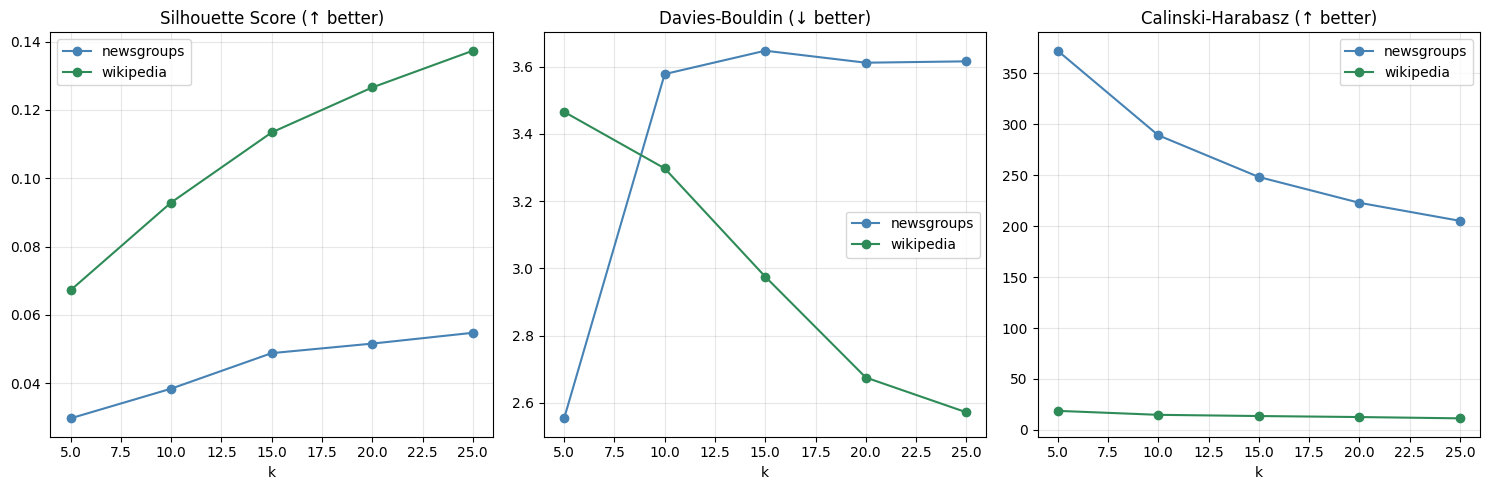

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = [
    ('silhouette', True, 'Silhouette Score (↑ better)'),
    ('davies_bouldin', False, 'Davies-Bouldin (↓ better)'),
    ('calinski_harabasz', True, 'Calinski-Harabasz (↑ better)'),
]
colors = {'newsgroups': 'steelblue', 'wikipedia': 'seagreen'}
for ax, (metric, higher_better, title) in zip(axes, metrics_to_plot):
    for dataset, grp in all_metrics.groupby('dataset'):
        best_per_k = grp.groupby('k')[metric].max() if higher_better else grp.groupby('k')[metric].min()
        ax.plot(best_per_k.index, best_per_k.values, 'o-', label=dataset, color=colors[dataset])
    ax.set_title(title); ax.set_xlabel('k'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/evaluation_cross_dataset.png', bbox_inches='tight')
plt.show()


## 6. t-SNE Visualization Comparison

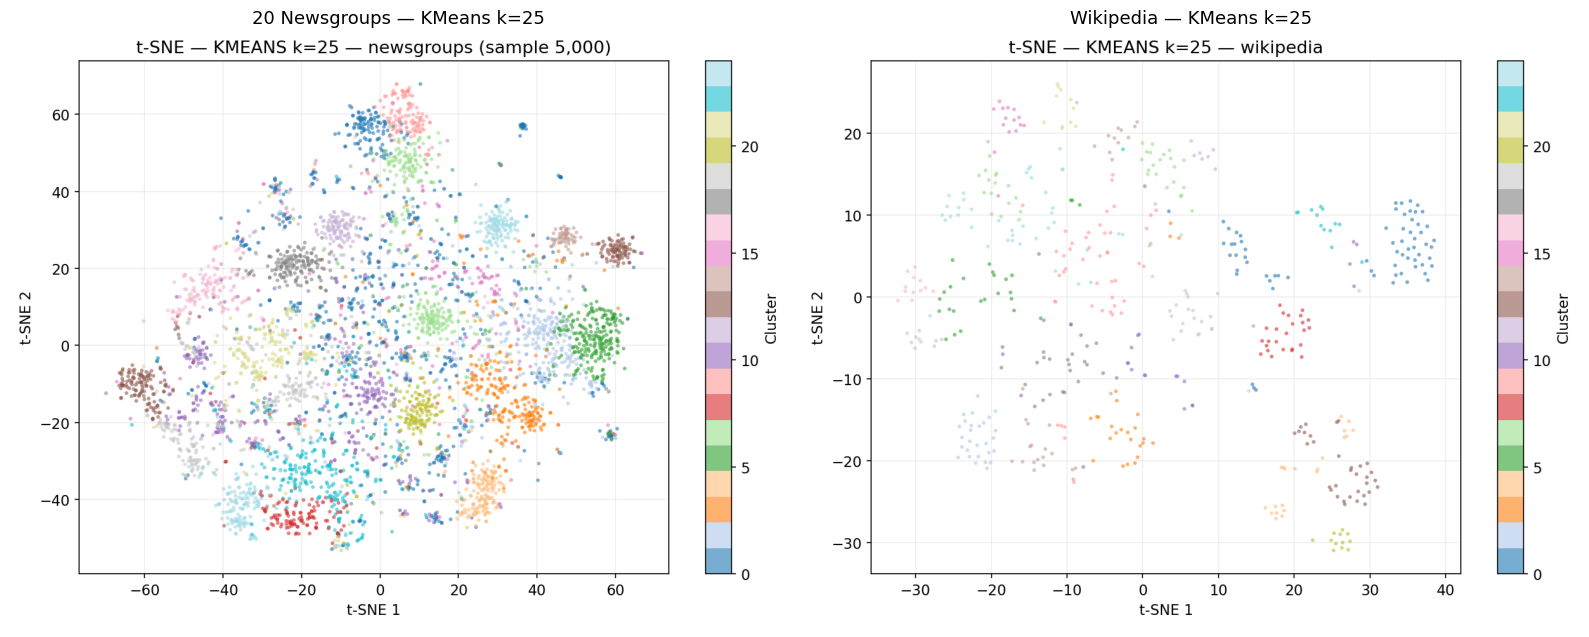

In [7]:
from PIL import Image
import os

plots = [
    ('../outputs/figures/tsne_kmeans_k25_newsgroups.png', '20 Newsgroups — KMeans k=25'),
    ('../outputs/figures/tsne_kmeans_k25_wikipedia.png',  'Wikipedia — KMeans k=25'),
]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (path, title) in zip(axes, plots):
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img); ax.axis('off'); ax.set_title(title, fontsize=13)
plt.tight_layout(); plt.show()


## 7. Conclusions

| Metric | 20 Newsgroups winner | Wikipedia winner |
|--------|---------------------|------------------|
| Silhouette | K-Means k=25 (0.055) | K-Means k=25 (0.137) |
| Davies-Bouldin | K-Means k=25 (3.62) | K-Means k=25 (2.57) |
| Calinski-Harabasz | K-Means k=5 (372) | K-Means k=5 (18.75) |

**Key findings:**
- K-Means consistently outperforms Hierarchical and GMM on silhouette.
- Wikipedia (shorter, topic-focused bios) clusters more cleanly (sil×2.5 higher).
- Hierarchical with `complete`/`average` linkage creates skewed clusters.
- GMM `tied` covariance matches K-Means closely — soft assignments may help borderline docs.
- Low overall silhouette on Newsgroups is expected: overlapping topics in natural language.